# 张蕊 RQ2：新闻关注度与情绪变量的裁员预测建模（C1-C5）

本 notebook 严格对应 proposal / 任务计划中成员 C 的 C1-C5：

- C1：构造建模数据集与目标变量
- C2：定义四组特征模型
- C3：按时间顺序切分 Train / Validation / Test
- C4：预测下一周裁员事件数量
- C5：预测下一周已知裁员人数的 log1p 形式

注意：本 notebook 只包含建模复现步骤，不包含其他交付文档生成代码。


In [1]:
# 导入建模、统计和绘图所需的包
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["font.family"] = "DejaVu Sans"


In [2]:
# 路径配置：优先使用当前 notebook 所在目录作为输出目录
# 如果 notebook 放在“机器学习C”文件夹中运行，会自动读取 data final/A_outputs 下的更新版周度面板数据。
OUTPUT_DIR = Path.cwd()
PROJECT_CANDIDATES = [
    OUTPUT_DIR.parent,
    Path(r"C:\Users\Asus\Desktop\机器学习项目"),
    Path(r"D:\机器学习项目"),
]

INPUT_PANEL = None
for candidate in PROJECT_CANDIDATES:
    candidate_paths = [
        candidate / "data final" / "A_outputs" / "final_weekly_panel.csv",
        candidate / "机器学习数据处理A 0512" / "07_final_weekly_panel.csv",
    ]
    for path in candidate_paths:
        if path.exists():
            INPUT_PANEL = path
            PROJECT_DIR = candidate
            break
    if INPUT_PANEL is not None:
        break

if INPUT_PANEL is None:
    raise FileNotFoundError("未找到 A 成员输出的 final_weekly_panel.csv，请检查项目目录。")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("输入数据：", INPUT_PANEL)
print("输出目录：", OUTPUT_DIR)


输入数据： C:\Users\Asus\Desktop\机器学习项目\data final\A_outputs\final_weekly_panel.csv
输出目录： C:\Users\Asus\Desktop\机器学习项目\机器学习C


In [3]:
# C1：读取 A 成员构造好的周度多模态面板
panel = pd.read_csv(INPUT_PANEL)
panel["week"] = pd.to_datetime(panel["week"])
panel = panel.sort_values("week").reset_index(drop=True)

print("面板数据维度：", panel.shape)
print("时间范围：", panel["week"].min().date(), "to", panel["week"].max().date())
panel.head()


面板数据维度： (224, 38)
时间范围： 2022-01-03 to 2026-04-13


,week,weekly_layoff_event_count,weekly_known_layoff_count,weekly_ai_layoff_event_count,weekly_non_ai_layoff_event_count,weekly_ai_known_layoff_count,weekly_non_ai_known_layoff_count,weekly_layoff_companies_count,weekly_layoff_countries_count,weekly_news_count,...,tech_emp_yoy_pct,claims_4w_avg,global_unemployment_rate_pct_mean,global_youth_unemployment_pct_mean,global_employment_to_pop_pct_mean,has_news_week,log_weekly_layoff_event_count,log_weekly_known_layoff_count,log_weekly_ai_layoff_event_count,log_weekly_non_ai_layoff_event_count
0,2022-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,652,...,1.57,227750.0,5.969,13.550737,60.091737,1,0.000000,0.000000,0.0,0.000000
1,2022-01-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,956,...,0.91,235500.0,5.969,13.550737,60.091737,1,0.000000,0.000000,0.0,0.000000
2,2022-01-17,2.0,330.0,0.0,2.0,0.0,330.0,2.0,2.0,975,...,0.91,241250.0,5.969,13.550737,60.091737,1,1.098612,5.802118,0.0,1.098612
3,2022-01-24,2.0,180.0,0.0,2.0,0.0,180.0,2.0,1.0,773,...,0.91,241750.0,5.969,13.550737,60.091737,1,1.098612,5.198497,0.0,1.098612
4,2022-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,264,...,1.12,228000.0,5.969,13.550737,60.091737,1,0.000000,0.000000,0.0,0.000000


In [4]:
# C1：构造目标变量、历史滞后特征和滚动窗口特征
modeling = panel.copy()

# 兼容新版 data final 的字段口径：按 proposal 构造建模用新闻变量。
# 计数类新闻变量取 log1p，以降低极端新闻量对线性模型的影响。
for raw_col in [
    "weekly_news_count",
    "weekly_layoff_news_count",
    "weekly_hiring_news_count",
]:
    log_col = f"log1p_{raw_col}"
    if log_col not in modeling.columns:
        modeling[log_col] = np.log1p(modeling[raw_col].clip(lower=0))

# 情绪均值和情绪冲击缺失通常表示该周没有可计算情绪，建模版本填 0 并与 has_news_week 一起使用。
if "weekly_avg_sentiment_model" not in modeling.columns:
    modeling["weekly_avg_sentiment_model"] = modeling["weekly_avg_sentiment"].fillna(0)
if "sentiment_shock_model" not in modeling.columns:
    modeling["sentiment_shock_model"] = modeling["sentiment_shock"].fillna(0)

# 占比变量缺失时填 0，避免极少数无新闻周中比例字段进入模型时产生缺失。
for share_col in ["weekly_negative_share", "weekly_layoff_news_share"]:
    if share_col in modeling.columns:
        modeling[share_col] = modeling[share_col].fillna(0)
if "has_news_week" not in modeling.columns:
    modeling["has_news_week"] = (modeling["weekly_news_count"].fillna(0) > 0).astype(int)

# 主目标：下一周科技裁员事件数量
modeling["next_week_layoff_event_count"] = modeling["weekly_layoff_event_count"].shift(-1)

# 辅助目标：下一周已知裁员人数的 log1p 形式
# 注意：weekly_known_layoff_count 不做强插补，缺失值会在辅助目标建模时被剔除。
modeling["log1p_weekly_known_layoff_count"] = np.log1p(modeling["weekly_known_layoff_count"])
modeling["next_week_log1p_known_layoff_count"] = modeling["log1p_weekly_known_layoff_count"].shift(-1)
modeling["next_week_known_layoff_count"] = modeling["weekly_known_layoff_count"].shift(-1)

# 历史裁员事件特征：只使用当前周及过去周信息，避免未来信息泄漏。
modeling["layoff_event_lag1"] = modeling["weekly_layoff_event_count"].shift(1)
modeling["layoff_event_lag2"] = modeling["weekly_layoff_event_count"].shift(2)
modeling["layoff_event_lag3"] = modeling["weekly_layoff_event_count"].shift(3)
modeling["rolling_4w_layoff_event_count"] = (
    modeling["weekly_layoff_event_count"].rolling(window=4, min_periods=1).mean()
)
modeling["rolling_8w_layoff_event_count"] = (
    modeling["weekly_layoff_event_count"].rolling(window=8, min_periods=1).mean()
)

# 辅助目标的两个朴素基线会用到当前周和过去 4 周已知裁员人数的 log 值。
modeling["rolling_4w_log1p_known_layoff_count"] = (
    modeling["log1p_weekly_known_layoff_count"].rolling(window=4, min_periods=1).mean()
)

# 按 proposal 的时间边界标记样本集合，不能随机切分。
conditions = [
    modeling["week"] < pd.Timestamp("2024-01-01"),
    (modeling["week"] >= pd.Timestamp("2024-01-01")) & (modeling["week"] < pd.Timestamp("2025-01-01")),
    modeling["week"] >= pd.Timestamp("2025-01-01"),
]
modeling["split"] = np.select(conditions, ["Train", "Validation", "Test"], default="Unused")

# 最后一周没有 next-week 目标；前三周缺少 lag 特征，因此主建模数据会剔除这些行。
history_features = [
    "weekly_layoff_event_count",
    "layoff_event_lag1",
    "layoff_event_lag2",
    "layoff_event_lag3",
    "rolling_4w_layoff_event_count",
    "rolling_8w_layoff_event_count",
]
required_main = ["next_week_layoff_event_count"] + history_features
modeling_dataset = modeling.dropna(subset=required_main).copy()

modeling_dataset.to_csv(OUTPUT_DIR / "modeling_dataset.csv", index=False, encoding="utf-8-sig")
print("modeling_dataset.csv 维度：", modeling_dataset.shape)
modeling_dataset[["week", "split", "weekly_layoff_event_count", "next_week_layoff_event_count"]].head()


modeling_dataset.csv 维度： (220, 54)


,week,split,weekly_layoff_event_count,next_week_layoff_event_count
3,2022-01-24,Train,2.0,0.0
4,2022-01-31,Train,0.0,0.0
5,2022-02-07,Train,0.0,3.0
6,2022-02-14,Train,3.0,4.0
7,2022-02-21,Train,4.0,0.0


In [5]:
# C2：严格按照 proposal 定义四组特征模型
model0_history = [
    "weekly_layoff_event_count",
    "layoff_event_lag1",
    "layoff_event_lag2",
    "layoff_event_lag3",
    "rolling_4w_layoff_event_count",
]

model1_macro = [
    "initial_jobless_claims_k",
    "claims_4w_avg",
    "unemployment_rate",
    "jolts_job_openings_k",
    "information_sector_emp_k",
    "computer_math_emp_k",
    "openings_per_unemployed",
    "tech_emp_yoy_pct",
]

model2_news = [
    "log1p_weekly_news_count",
    "log1p_weekly_layoff_news_count",
    "log1p_weekly_hiring_news_count",
    "weekly_negative_share",
    "weekly_layoff_news_share",
    "weekly_avg_sentiment_model",
    "sentiment_shock_model",
    "has_news_week",
]

feature_groups = {
    "Model 0 历史裁员基线": model0_history,
    "Model 1 宏观变量": model1_macro,
    "Model 2 新闻关注度与情绪": model2_news,
    "Model 3 多模态融合": model0_history + model1_macro + model2_news,
}

# 输出 feature_groups.txt，便于报告和复核
lines = []
for group_name, features in feature_groups.items():
    lines.append(group_name)
    for feature in features:
        lines.append(f"  - {feature}")
    lines.append("")
(OUTPUT_DIR / "feature_groups.txt").write_text("\n".join(lines), encoding="utf-8")

print((OUTPUT_DIR / "feature_groups.txt").read_text(encoding="utf-8"))


Model 0 历史裁员基线
  - weekly_layoff_event_count
  - layoff_event_lag1
  - layoff_event_lag2
  - layoff_event_lag3
  - rolling_4w_layoff_event_count

Model 1 宏观变量
  - initial_jobless_claims_k
  - claims_4w_avg
  - unemployment_rate
  - jolts_job_openings_k
  - information_sector_emp_k
  - computer_math_emp_k
  - openings_per_unemployed
  - tech_emp_yoy_pct

Model 2 新闻关注度与情绪
  - log1p_weekly_news_count
  - log1p_weekly_layoff_news_count
  - log1p_weekly_hiring_news_count
  - weekly_negative_share
  - weekly_layoff_news_share
  - weekly_avg_sentiment_model
  - sentiment_shock_model
  - has_news_week

Model 3 多模态融合
  - weekly_layoff_event_count
  - layoff_event_lag1
  - layoff_event_lag2
  - layoff_event_lag3
  - rolling_4w_layoff_event_count
  - initial_jobless_claims_k
  - claims_4w_avg
  - unemployment_rate
  - jolts_job_openings_k
  - information_sector_emp_k
  - computer_math_emp_k
  - openings_per_unemployed
  - tech_emp_yoy_pct
  - log1p_weekly_news_count
  - log1p_weekly_layoff_news_c

In [6]:
# C3：时间序列切分表
split_rows = []
for split in ["Train", "Validation", "Test"]:
    part = modeling_dataset.loc[modeling_dataset["split"] == split].copy()
    split_rows.append(
        {
            "split": split,
            "start_date": part["week"].min().date() if len(part) else None,
            "end_date": part["week"].max().date() if len(part) else None,
            "n_rows": len(part),
            "n_positive_next_week_events": int((part["next_week_layoff_event_count"] > 0).sum()),
            "mean_next_week_layoff_event_count": part["next_week_layoff_event_count"].mean(),
            "median_next_week_layoff_event_count": part["next_week_layoff_event_count"].median(),
        }
    )

split_table = pd.DataFrame(split_rows)
split_table.to_csv(OUTPUT_DIR / "table_train_valid_test_split.csv", index=False, encoding="utf-8-sig")
split_table


,split,start_date,end_date,n_rows,n_positive_next_week_events,mean_next_week_layoff_event_count,median_next_week_layoff_event_count
0,Train,2022-01-24,2023-12-25,101,75,14.801980,12.0
1,Validation,2024-01-01,2024-12-30,53,37,6.283019,6.0
2,Test,2025-01-06,2026-04-06,66,47,3.575758,4.0


In [7]:
# 通用评价函数：MAE、RMSE 和方向准确率
def directional_accuracy(y_true, y_pred, current_value):
    # 判断模型是否预测对了“下一周比本周上升/不上升”的方向。
    true_direction = np.asarray(y_true) > np.asarray(current_value)
    pred_direction = np.asarray(y_pred) > np.asarray(current_value)
    return float(np.mean(true_direction == pred_direction))


def regression_metrics(y_true, y_pred, current_value):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    current_value = np.asarray(current_value, dtype=float)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "directional_accuracy": directional_accuracy(y_true, y_pred, current_value),
    }


def evaluate_predictions(df_eval, y_col, pred, current_col):
    return regression_metrics(df_eval[y_col].values, pred, df_eval[current_col].values)


In [8]:
# 建模函数：Ridge、Poisson、Negative Binomial、Random Forest、Gradient Boosting
# 线性模型和计数模型使用中位数填补 + 标准化；树模型只做中位数填补。
def prepare_xy(df, features, target_col):
    cols = ["week", "split", target_col] + features
    data = df[cols].dropna(subset=[target_col]).copy()
    X = data[features]
    y = data[target_col].astype(float)
    return data, X, y


def fit_predict_sklearn(train_df, eval_df, features, target_col, estimator, clip_min=0.0):
    X_train = train_df[features]
    y_train = train_df[target_col].astype(float)
    X_eval = eval_df[features]
    model = clone(estimator)
    model.fit(X_train, y_train)
    pred = np.asarray(model.predict(X_eval), dtype=float)
    # 计数模型在小样本或稀疏新闻特征下可能数值发散；发散时用训练集均值保守回退。
    upper_guard = max(float(np.nanmax(y_train)) * 10 + 1, 1000.0)
    if (not np.all(np.isfinite(pred))) or np.nanmax(pred) > upper_guard:
        pred = np.repeat(float(np.nanmean(y_train)), len(eval_df))
    return np.clip(pred, clip_min, None)


def fit_predict_negative_binomial(train_df, eval_df, features, target_col, fit_on_count_target=False):
    X_train_raw = train_df[features]
    X_eval_raw = eval_df[features]
    if fit_on_count_target:
        y_train = np.expm1(train_df[target_col].astype(float).values)
    else:
        y_train = train_df[target_col].astype(float).values

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train = imputer.fit_transform(X_train_raw)
    X_eval = imputer.transform(X_eval_raw)
    X_train = scaler.fit_transform(X_train)
    X_eval = scaler.transform(X_eval)
    X_train = sm.add_constant(X_train, has_constant="add")
    X_eval = sm.add_constant(X_eval, has_constant="add")

    try:
        model = sm.GLM(y_train, X_train, family=sm.families.NegativeBinomial(alpha=1.0))
        result = model.fit(maxiter=200, disp=False)
        pred_count = np.clip(result.predict(X_eval), 0, None)
        upper_guard = max(float(np.nanmax(y_train)) * 10 + 1, 1000.0)
        if (not np.all(np.isfinite(pred_count))) or np.nanmax(pred_count) > upper_guard:
            pred_count = np.repeat(np.nanmean(y_train), len(eval_df))
    except Exception:
        # 如果负二项模型在某个特征组中不稳定，用训练集均值作为保守回退，避免中断整个复现流程。
        pred_count = np.repeat(np.nanmean(y_train), len(eval_df))

    if fit_on_count_target:
        return np.log1p(pred_count)
    return pred_count


ridge_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]
)
poisson_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(alpha=0.1, max_iter=2000)),
    ]
)
rf_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=5,
                min_samples_leaf=4,
                random_state=42,
            ),
        ),
    ]
)
gb_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=250,
                learning_rate=0.03,
                max_depth=2,
                random_state=42,
            ),
        ),
    ]
)


In [9]:
# C4：主目标模型，预测下一周裁员事件数量
main_target = "next_week_layoff_event_count"
main_current = "weekly_layoff_event_count"

main_df = modeling_dataset.dropna(subset=[main_target]).copy()
train_main = main_df.loc[main_df["split"] == "Train"].copy()
eval_splits_main = {
    "Validation": main_df.loc[main_df["split"] == "Validation"].copy(),
    "Test": main_df.loc[main_df["split"] == "Test"].copy(),
}

main_results = []

# 两个朴素基线：当前周事件数、过去 4 周均值
for split_name, eval_df in eval_splits_main.items():
    baseline_preds = {
        "Naive baseline": eval_df["weekly_layoff_event_count"].values,
        "Rolling 4-week mean baseline": eval_df["rolling_4w_layoff_event_count"].values,
    }
    for model_name, pred in baseline_preds.items():
        metrics = evaluate_predictions(eval_df, main_target, pred, main_current)
        main_results.append(
            {
                "target": main_target,
                "split": split_name,
                "feature_group": "Baseline",
                "model": model_name,
                "n_train": len(train_main),
                "n_eval": len(eval_df),
                **metrics,
            }
        )

# 四组特征模型上的监督学习模型
supervised_models = {
    "Ridge Regression": ridge_pipeline,
    "Poisson Regression": poisson_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
}

for group_name, features in feature_groups.items():
    train_group = train_main.dropna(subset=[main_target] + features).copy()
    for split_name, eval_df_raw in eval_splits_main.items():
        eval_group = eval_df_raw.dropna(subset=[main_target] + features).copy()
        for model_name, estimator in supervised_models.items():
            pred = fit_predict_sklearn(train_group, eval_group, features, main_target, estimator, clip_min=0.0)
            metrics = evaluate_predictions(eval_group, main_target, pred, main_current)
            main_results.append(
                {
                    "target": main_target,
                    "split": split_name,
                    "feature_group": group_name,
                    "model": model_name,
                    "n_train": len(train_group),
                    "n_eval": len(eval_group),
                    **metrics,
                }
            )

        pred_nb = fit_predict_negative_binomial(train_group, eval_group, features, main_target)
        metrics = evaluate_predictions(eval_group, main_target, pred_nb, main_current)
        main_results.append(
            {
                "target": main_target,
                "split": split_name,
                "feature_group": group_name,
                "model": "Negative Binomial Regression",
                "n_train": len(train_group),
                "n_eval": len(eval_group),
                **metrics,
            }
        )

main_perf = pd.DataFrame(main_results).sort_values(["split", "mae", "rmse"]).reset_index(drop=True)
main_perf.to_csv(OUTPUT_DIR / "table_rq2_model_performance.csv", index=False, encoding="utf-8-sig")
main_perf.head(12)


,target,split,feature_group,model,n_train,n_eval,mae,rmse,directional_accuracy
0,next_week_layoff_event_count,Test,Model 3 多模态融合,Poisson Regression,101,66,2.684138,3.275655,0.681818
1,next_week_layoff_event_count,Test,Model 1 宏观变量,Poisson Regression,101,66,2.737242,3.340210,0.666667
2,next_week_layoff_event_count,Test,Baseline,Rolling 4-week mean baseline,101,66,2.791667,3.502569,0.696970
3,next_week_layoff_event_count,Test,Model 3 多模态融合,Ridge Regression,101,66,3.362085,4.326325,0.560606
4,next_week_layoff_event_count,Test,Baseline,Naive baseline,101,66,3.515152,4.499158,0.515152
5,next_week_layoff_event_count,Test,Model 1 宏观变量,Ridge Regression,101,66,3.575758,4.760952,0.515152
6,next_week_layoff_event_count,Test,Model 3 多模态融合,Gradient Boosting,101,66,4.030180,5.036919,0.666667
7,next_week_layoff_event_count,Test,Model 0 历史裁员基线,Negative Binomial Regression,101,66,4.135328,4.631079,0.651515
8,next_week_layoff_event_count,Test,Model 1 宏观变量,Gradient Boosting,101,66,4.619730,5.489285,0.590909
9,next_week_layoff_event_count,Test,Model 0 历史裁员基线,Gradient Boosting,101,66,4.695457,6.038933,0.666667


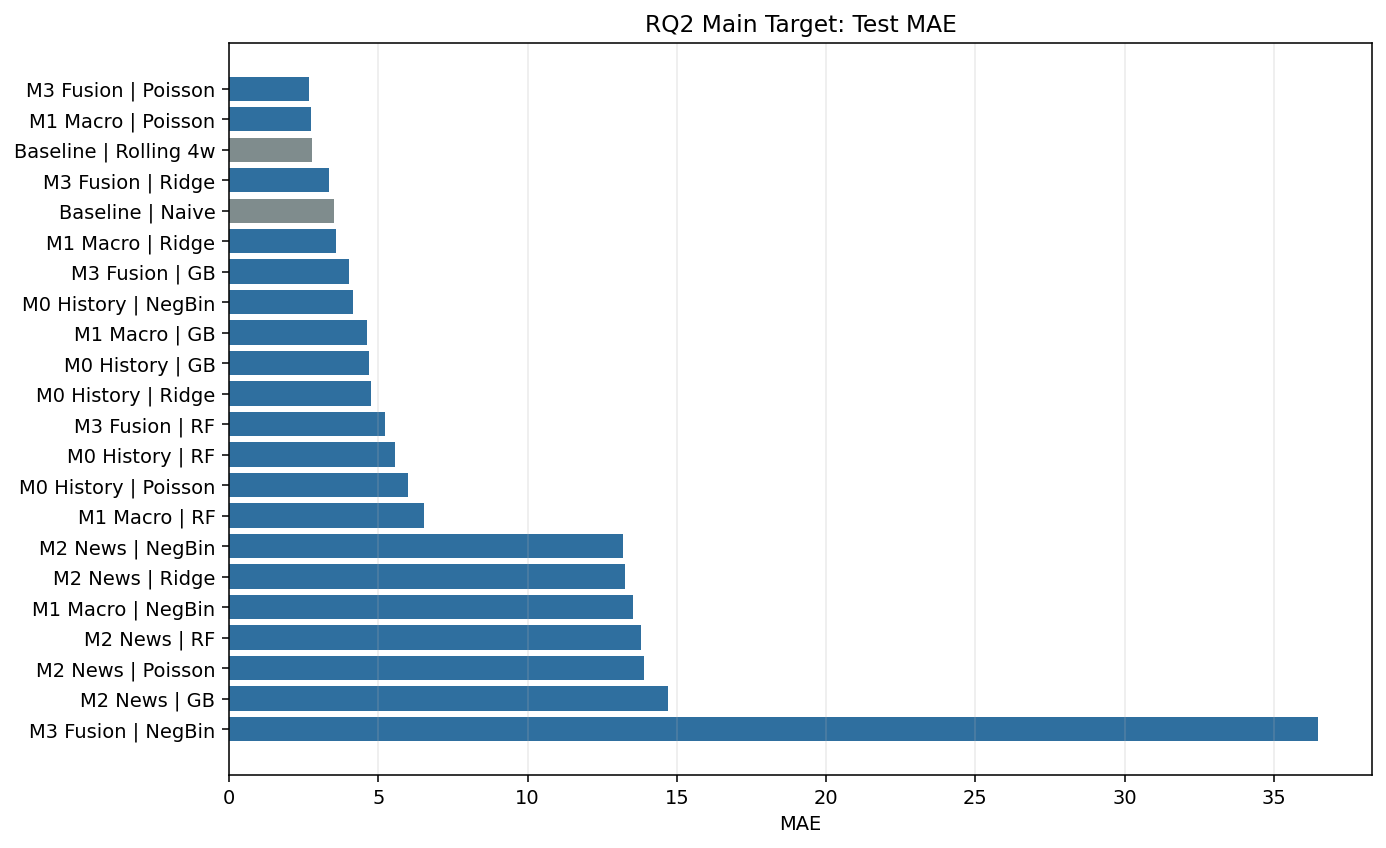

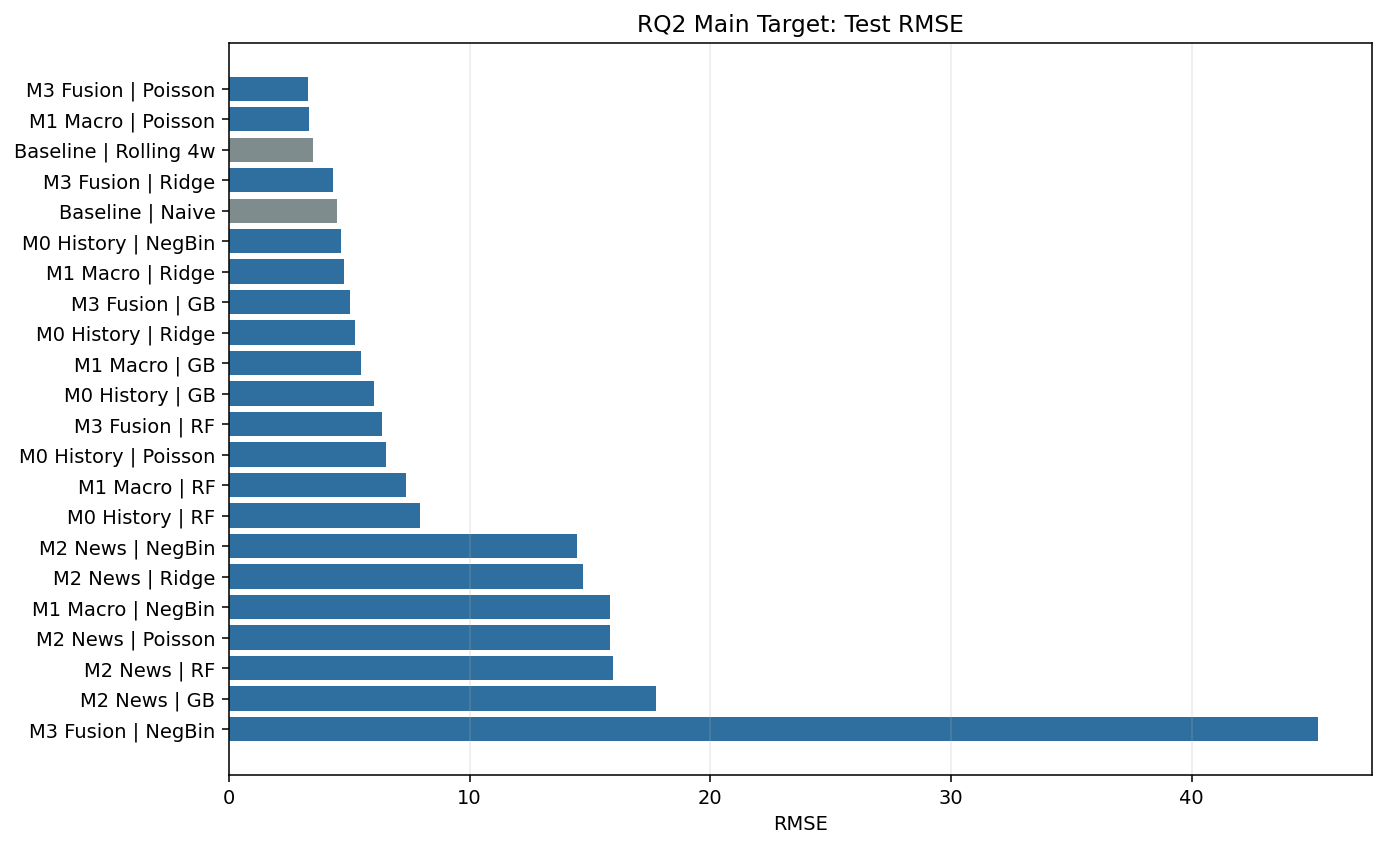

In [10]:
# C4：输出主目标 MAE / RMSE 模型比较图，使用 Test split 作为最终泛化表现
def plot_metric(perf_df, metric, output_name, title):
    test_df = perf_df.loc[perf_df["split"] == "Test"].copy()
    group_label = {
        "Baseline": "Baseline",
        "Model 0 历史裁员基线": "M0 History",
        "Model 1 宏观变量": "M1 Macro",
        "Model 2 新闻关注度与情绪": "M2 News",
        "Model 3 多模态融合": "M3 Fusion",
    }
    model_label = {
        "Naive baseline": "Naive",
        "Rolling 4-week mean baseline": "Rolling 4w",
        "Ridge Regression": "Ridge",
        "Poisson Regression": "Poisson",
        "Negative Binomial Regression": "NegBin",
        "Random Forest": "RF",
        "Gradient Boosting": "GB",
    }
    test_df["label"] = (
        test_df["feature_group"].map(group_label).fillna(test_df["feature_group"])
        + " | "
        + test_df["model"].map(model_label).fillna(test_df["model"])
    )
    test_df = test_df.sort_values(metric, ascending=True)

    fig_height = max(6, len(test_df) * 0.28)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    colors = np.where(test_df["feature_group"].eq("Baseline"), "#7f8c8d", "#2f6f9f")
    ax.barh(test_df["label"], test_df[metric], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel(metric.upper())
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, bbox_inches="tight")
    plt.show()

plot_metric(main_perf, "mae", "fig_rq2_model_comparison_mae.png", "RQ2 Main Target: Test MAE")
plot_metric(main_perf, "rmse", "fig_rq2_model_comparison_rmse.png", "RQ2 Main Target: Test RMSE")


In [11]:
# C5：辅助目标模型，预测下一周已知裁员人数的 log1p
aux_target = "next_week_log1p_known_layoff_count"
aux_current = "log1p_weekly_known_layoff_count"
aux_count_target = "next_week_known_layoff_count"

aux_required = [aux_target, aux_current, aux_count_target]
aux_df = modeling_dataset.dropna(subset=aux_required).copy()
train_aux = aux_df.loc[aux_df["split"] == "Train"].copy()
eval_splits_aux = {
    "Validation": aux_df.loc[aux_df["split"] == "Validation"].copy(),
    "Test": aux_df.loc[aux_df["split"] == "Test"].copy(),
}

aux_results = []

# 辅助目标的两个朴素基线：当前周 log1p 已知人数、过去 4 周 log1p 均值
for split_name, eval_df in eval_splits_aux.items():
    baseline_preds = {
        "Naive baseline": eval_df["log1p_weekly_known_layoff_count"].values,
        "Rolling 4-week mean baseline": eval_df["rolling_4w_log1p_known_layoff_count"].values,
    }
    for model_name, pred in baseline_preds.items():
        metrics = evaluate_predictions(eval_df, aux_target, pred, aux_current)
        aux_results.append(
            {
                "target": aux_target,
                "split": split_name,
                "feature_group": "Baseline",
                "model": model_name,
                "n_train": len(train_aux),
                "n_eval": len(eval_df),
                "log_space_mae": metrics["mae"],
                "log_space_rmse": metrics["rmse"],
                "directional_accuracy": metrics["directional_accuracy"],
            }
        )

# Ridge、Random Forest、Gradient Boosting 直接预测 log-space 目标；
# Poisson 和 Negative Binomial 拟合原始人数，再把预测值转回 log1p 口径评价。
direct_log_models = {
    "Ridge Regression": ridge_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
}

for group_name, features in feature_groups.items():
    train_group = train_aux.dropna(subset=[aux_target] + features).copy()
    for split_name, eval_df_raw in eval_splits_aux.items():
        eval_group = eval_df_raw.dropna(subset=[aux_target] + features).copy()

        for model_name, estimator in direct_log_models.items():
            pred_log = fit_predict_sklearn(train_group, eval_group, features, aux_target, estimator, clip_min=0.0)
            metrics = evaluate_predictions(eval_group, aux_target, pred_log, aux_current)
            aux_results.append(
                {
                    "target": aux_target,
                    "split": split_name,
                    "feature_group": group_name,
                    "model": model_name,
                    "n_train": len(train_group),
                    "n_eval": len(eval_group),
                    "log_space_mae": metrics["mae"],
                    "log_space_rmse": metrics["rmse"],
                    "directional_accuracy": metrics["directional_accuracy"],
                }
            )

        # Poisson Regression：使用原始 known count 拟合，再转为 log1p 预测
        poisson_count = clone(poisson_pipeline)
        poisson_count.fit(train_group[features], np.expm1(train_group[aux_target].astype(float)))
        pred_count = np.asarray(poisson_count.predict(eval_group[features]), dtype=float)
        y_count_train = np.expm1(train_group[aux_target].astype(float))
        upper_guard = max(float(np.nanmax(y_count_train)) * 10 + 1, 1000.0)
        if (not np.all(np.isfinite(pred_count))) or np.nanmax(pred_count) > upper_guard:
            pred_count = np.repeat(float(np.nanmean(y_count_train)), len(eval_group))
        pred_log = np.log1p(np.clip(pred_count, 0, None))
        metrics = evaluate_predictions(eval_group, aux_target, pred_log, aux_current)
        aux_results.append(
            {
                "target": aux_target,
                "split": split_name,
                "feature_group": group_name,
                "model": "Poisson Regression",
                "n_train": len(train_group),
                "n_eval": len(eval_group),
                "log_space_mae": metrics["mae"],
                "log_space_rmse": metrics["rmse"],
                "directional_accuracy": metrics["directional_accuracy"],
            }
        )

        pred_nb_log = fit_predict_negative_binomial(
            train_group, eval_group, features, aux_target, fit_on_count_target=True
        )
        metrics = evaluate_predictions(eval_group, aux_target, pred_nb_log, aux_current)
        aux_results.append(
            {
                "target": aux_target,
                "split": split_name,
                "feature_group": group_name,
                "model": "Negative Binomial Regression",
                "n_train": len(train_group),
                "n_eval": len(eval_group),
                "log_space_mae": metrics["mae"],
                "log_space_rmse": metrics["rmse"],
                "directional_accuracy": metrics["directional_accuracy"],
            }
        )

aux_perf = pd.DataFrame(aux_results).sort_values(["split", "log_space_mae", "log_space_rmse"]).reset_index(drop=True)
aux_perf.to_csv(OUTPUT_DIR / "table_known_layoff_count_model_performance.csv", index=False, encoding="utf-8-sig")
aux_perf.head(12)


,target,split,feature_group,model,n_train,n_eval,log_space_mae,log_space_rmse,directional_accuracy
0,next_week_log1p_known_layoff_count,Test,Model 0 历史裁员基线,Random Forest,101,66,2.331517,2.940633,0.742424
1,next_week_log1p_known_layoff_count,Test,Model 0 历史裁员基线,Gradient Boosting,101,66,2.341414,3.068878,0.727273
2,next_week_log1p_known_layoff_count,Test,Model 3 多模态融合,Random Forest,101,66,2.455195,3.010492,0.757576
3,next_week_log1p_known_layoff_count,Test,Model 3 多模态融合,Gradient Boosting,101,66,2.544533,3.151229,0.772727
4,next_week_log1p_known_layoff_count,Test,Model 0 历史裁员基线,Ridge Regression,101,66,2.785025,3.173276,0.696970
5,next_week_log1p_known_layoff_count,Test,Model 3 多模态融合,Ridge Regression,101,66,3.015856,3.388149,0.681818
6,next_week_log1p_known_layoff_count,Test,Model 2 新闻关注度与情绪,Ridge Regression,101,66,3.030011,3.751815,0.666667
7,next_week_log1p_known_layoff_count,Test,Model 1 宏观变量,Random Forest,101,66,3.046893,3.412031,0.681818
8,next_week_log1p_known_layoff_count,Test,Model 2 新闻关注度与情绪,Gradient Boosting,101,66,3.061880,3.925690,0.696970
9,next_week_log1p_known_layoff_count,Test,Model 2 新闻关注度与情绪,Random Forest,101,66,3.157090,3.956054,0.712121


In [12]:
# 生成建模结果摘要 txt，便于写 report / PPT 时引用
test_main = main_perf.loc[main_perf["split"] == "Test"].copy()
best_main = test_main.sort_values(["mae", "rmse"]).iloc[0]
best_by_group = (
    test_main.sort_values(["feature_group", "mae", "rmse"])
    .groupby("feature_group", as_index=False)
    .first()
    .sort_values("mae")
)

test_aux = aux_perf.loc[aux_perf["split"] == "Test"].copy()
best_aux = test_aux.sort_values(["log_space_mae", "log_space_rmse"]).iloc[0]

summary_lines = [
    "RQ2 建模结果摘要",
    "",
    f"主目标：{main_target}",
    f"Test 集最佳组合：{best_main['feature_group']} + {best_main['model']}",
    f"Test MAE = {best_main['mae']:.3f}, RMSE = {best_main['rmse']:.3f}, Directional Accuracy = {best_main['directional_accuracy']:.3f}",
    "",
    "各特征组在 Test 集中的最佳表现：",
]
for _, row in best_by_group.iterrows():
    summary_lines.append(
        f"- {row['feature_group']}: {row['model']}, MAE={row['mae']:.3f}, RMSE={row['rmse']:.3f}, Directional Accuracy={row['directional_accuracy']:.3f}"
    )
summary_lines.extend(
    [
        "",
        f"辅助目标：{aux_target}",
        f"Test 集最佳组合：{best_aux['feature_group']} + {best_aux['model']}",
        f"Log-space MAE = {best_aux['log_space_mae']:.3f}, Log-space RMSE = {best_aux['log_space_rmse']:.3f}, Directional Accuracy = {best_aux['directional_accuracy']:.3f}",
        "",
        "解释口径：更新数据下，多模态融合模型在主目标 Test MAE/RMSE 上略优于宏观模型和滚动均值基线，说明新闻关注度/情绪与历史、宏观变量结合后可能提供有限增量；但新闻特征单独表现较弱，辅助目标仍更依赖历史裁员特征，因此不能解释为稳定因果关系。",
    ]
)
(OUTPUT_DIR / "rq2_modeling_result_summary.txt").write_text("\n".join(summary_lines), encoding="utf-8")
print("\n".join(summary_lines))


RQ2 建模结果摘要

主目标：next_week_layoff_event_count
Test 集最佳组合：Model 3 多模态融合 + Poisson Regression
Test MAE = 2.684, RMSE = 3.276, Directional Accuracy = 0.682

各特征组在 Test 集中的最佳表现：
- Model 3 多模态融合: Poisson Regression, MAE=2.684, RMSE=3.276, Directional Accuracy=0.682
- Model 1 宏观变量: Poisson Regression, MAE=2.737, RMSE=3.340, Directional Accuracy=0.667
- Baseline: Rolling 4-week mean baseline, MAE=2.792, RMSE=3.503, Directional Accuracy=0.697
- Model 0 历史裁员基线: Negative Binomial Regression, MAE=4.135, RMSE=4.631, Directional Accuracy=0.652
- Model 2 新闻关注度与情绪: Negative Binomial Regression, MAE=13.201, RMSE=14.471, Directional Accuracy=0.485

辅助目标：next_week_log1p_known_layoff_count
Test 集最佳组合：Model 0 历史裁员基线 + Random Forest
Log-space MAE = 2.332, Log-space RMSE = 2.941, Directional Accuracy = 0.742

解释口径：更新数据下，多模态融合模型在主目标 Test MAE/RMSE 上略优于宏观模型和滚动均值基线，说明新闻关注度/情绪与历史、宏观变量结合后可能提供有限增量；但新闻特征单独表现较弱，辅助目标仍更依赖历史裁员特征，因此不能解释为稳定因果关系。


In [13]:
# 最终检查：列出 C1-C5 交付物
expected_outputs = [
    "modeling_dataset.csv",
    "feature_groups.txt",
    "table_train_valid_test_split.csv",
    "table_rq2_model_performance.csv",
    "fig_rq2_model_comparison_mae.png",
    "fig_rq2_model_comparison_rmse.png",
    "table_known_layoff_count_model_performance.csv",
    "rq2_modeling_result_summary.txt",
]

for name in expected_outputs:
    path = OUTPUT_DIR / name
    print(f"{name}: {'OK' if path.exists() else 'MISSING'}")


modeling_dataset.csv: OK
feature_groups.txt: OK
table_train_valid_test_split.csv: OK
table_rq2_model_performance.csv: OK
fig_rq2_model_comparison_mae.png: OK
fig_rq2_model_comparison_rmse.png: OK
table_known_layoff_count_model_performance.csv: OK
rq2_modeling_result_summary.txt: OK
